# Introduction to Graphs with NetworkX

This notebook introduces the basics of creating and visualizing graphs using NetworkX.

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

## Creating a Simple Undirected Graph

Let's start by creating a simple undirected graph and adding nodes and edges.

In [2]:
# Create an empty undirected graph
G = nx.Graph()

# Add nodes
G.add_node(1)
G.add_node(2)
G.add_node(3)
G.add_nodes_from([4, 5, 6])

# Add edges
G.add_edge(1, 2)
G.add_edge(1, 3)
G.add_edges_from([(2, 3), (3, 4), (4, 5), (5, 6), (6, 1)])

print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print(f"Nodes: {G.nodes()}")
print(f"Edges: {G.edges()}")

Number of nodes: 6
Number of edges: 7
Nodes: [1, 2, 3, 4, 5, 6]
Edges: [(1, 2), (1, 3), (1, 6), (2, 3), (3, 4), (4, 5), (5, 6)]


## Visualizing the Graph

C:\Users\Soumyadipta\AppData\Local\Temp\ipykernel_40944\1910317026.py:8: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


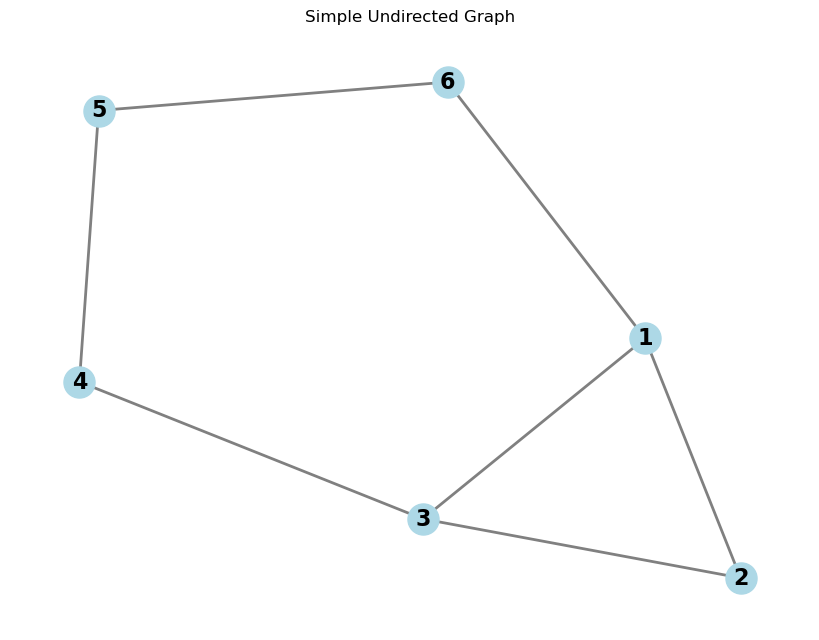

In [3]:
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='lightblue', 
        node_size=500, font_size=16, font_weight='bold',
        edge_color='gray', width=2)
plt.title("Simple Undirected Graph")
plt.axis('off')
plt.tight_layout()
plt.show()

## Creating a Directed Graph

Directed graphs have edges with directions.

In [4]:
# Create a directed graph
DG = nx.DiGraph()

# Add edges (automatically creates nodes)
DG.add_edges_from([
    ('A', 'B'),
    ('A', 'C'),
    ('B', 'C'),
    ('B', 'D'),
    ('C', 'D'),
    ('D', 'A')
])

print(f"Number of nodes: {DG.number_of_nodes()}")
print(f"Number of edges: {DG.number_of_edges()}")

Number of nodes: 4
Number of edges: 6


C:\Users\Soumyadipta\AppData\Local\Temp\ipykernel_40944\3377081335.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


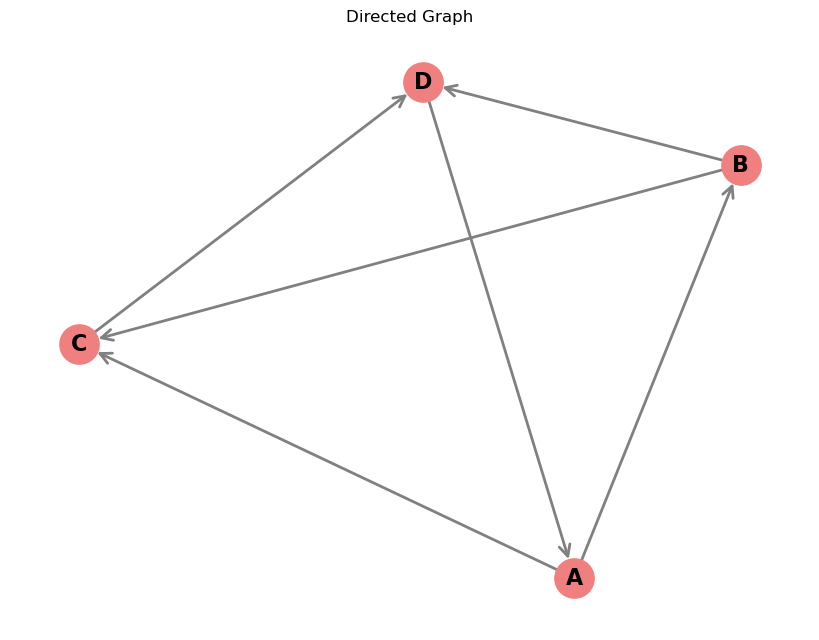

In [5]:
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(DG, seed=42)
nx.draw(DG, pos, with_labels=True, node_color='lightcoral', 
        node_size=800, font_size=16, font_weight='bold',
        edge_color='gray', width=2, arrows=True, 
        arrowsize=20, arrowstyle='->')
plt.title("Directed Graph")
plt.axis('off')
plt.tight_layout()
plt.show()

## Creating a Weighted Graph

Weighted graphs have values (weights) associated with their edges.

In [6]:
# Create a weighted graph
WG = nx.Graph()

# Add weighted edges
WG.add_edge('X', 'Y', weight=0.5)
WG.add_edge('X', 'Z', weight=1.5)
WG.add_edge('Y', 'Z', weight=2.0)
WG.add_edge('Y', 'W', weight=1.0)
WG.add_edge('Z', 'W', weight=0.8)

# Get edge weights
for (u, v, d) in WG.edges(data=True):
    print(f"Edge {u}-{v}: weight = {d['weight']}")

Edge X-Y: weight = 0.5
Edge X-Z: weight = 1.5
Edge Y-Z: weight = 2.0
Edge Y-W: weight = 1.0
Edge Z-W: weight = 0.8


C:\Users\Soumyadipta\AppData\Local\Temp\ipykernel_40944\2194142213.py:13: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


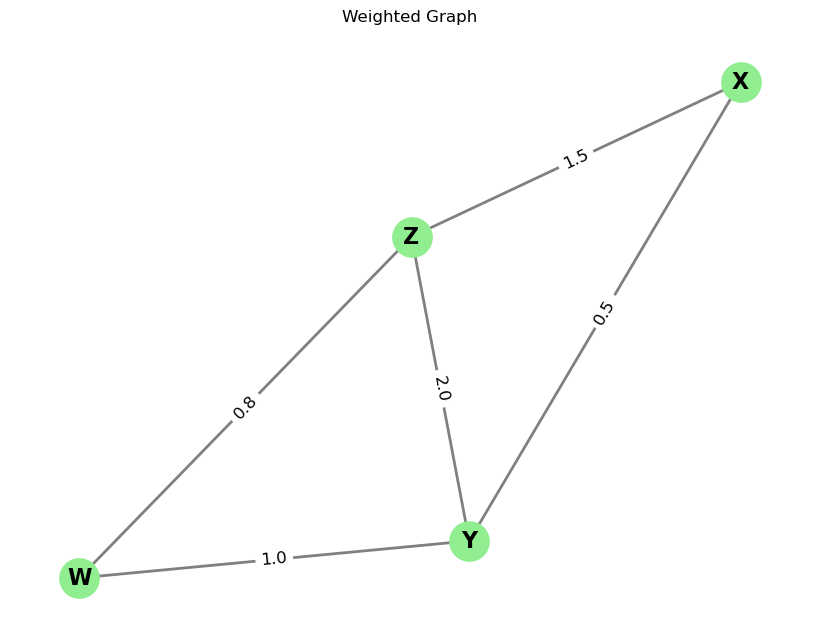

In [7]:
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(WG, seed=42)
nx.draw(WG, pos, with_labels=True, node_color='lightgreen', 
        node_size=800, font_size=16, font_weight='bold',
        edge_color='gray', width=2)

# Draw edge labels with weights
edge_labels = nx.get_edge_attributes(WG, 'weight')
nx.draw_networkx_edge_labels(WG, pos, edge_labels, font_size=12)

plt.title("Weighted Graph")
plt.axis('off')
plt.tight_layout()
plt.show()

## Common Graph Types

NetworkX provides functions to create common graph structures.

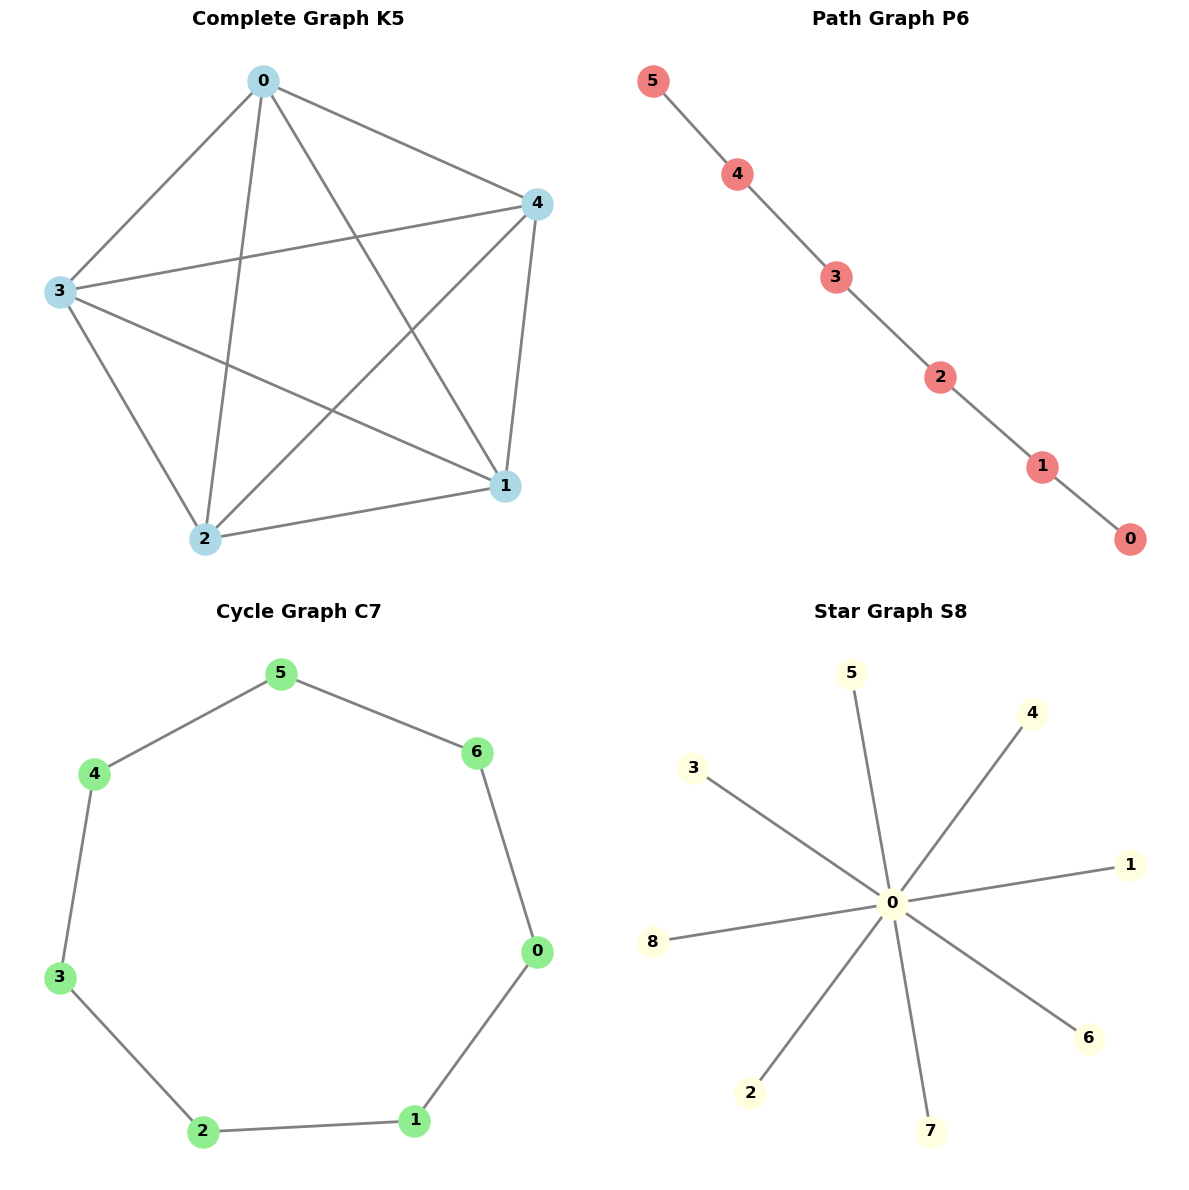

In [8]:
# Complete graph
K5 = nx.complete_graph(5)

# Path graph
P6 = nx.path_graph(6)

# Cycle graph
C7 = nx.cycle_graph(7)

# Star graph
S8 = nx.star_graph(8)

# Visualize them
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

graphs = [K5, P6, C7, S8]
titles = ['Complete Graph K5', 'Path Graph P6', 'Cycle Graph C7', 'Star Graph S8']
colors = ['lightblue', 'lightcoral', 'lightgreen', 'lightyellow']

for ax, g, title, color in zip(axes.flat, graphs, titles, colors):
    pos = nx.spring_layout(g, seed=42)
    nx.draw(g, pos, ax=ax, with_labels=True, node_color=color,
            node_size=500, font_size=12, font_weight='bold',
            edge_color='gray', width=2)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

## Random Graphs

Generate random graphs using various models.

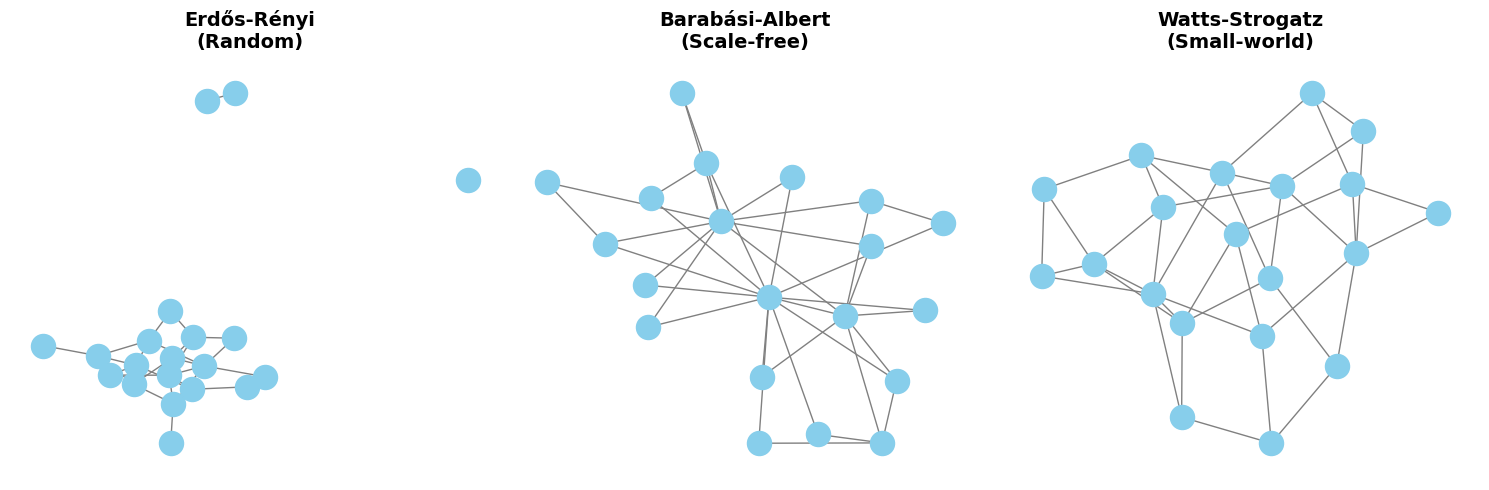

In [9]:
# Erdős-Rényi random graph
ER = nx.erdos_renyi_graph(n=20, p=0.15, seed=42)

# Barabási-Albert preferential attachment
BA = nx.barabasi_albert_graph(n=20, m=2, seed=42)

# Watts-Strogatz small-world
WS = nx.watts_strogatz_graph(n=20, k=4, p=0.3, seed=42)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

graphs = [ER, BA, WS]
titles = ['Erdős-Rényi\n(Random)', 'Barabási-Albert\n(Scale-free)', 'Watts-Strogatz\n(Small-world)']

for ax, g, title in zip(axes, graphs, titles):
    pos = nx.spring_layout(g, seed=42)
    nx.draw(g, pos, ax=ax, node_color='skyblue',
            node_size=300, with_labels=False,
            edge_color='gray', width=1)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

## Exercise

Try creating your own graphs:
1. Create a graph representing a social network (friends)
2. Create a directed graph representing web pages with links
3. Create a weighted graph representing cities with distances

In [10]:
# Your code here
